# BEBM MLP: all visible-field rules

This notebook compares all BEBM MLP variants that differ only in how the visible field `h` is handled:

- fixed stored `h`, initialized from data frequencies and not trained;
- post-update formula `h`, stored in the checkpoint after being recomputed from the MLP;
- gradient-trained `h`, stored as a learned parameter;
- zero-init gradient-trained `h`, if downloaded locally;
- differentiable constrained formula `h`, if downloaded locally, where the effective field is computed from the current weights and is not an independent checkpoint tensor.

The main question is whether the formula guides the way a learned `h` evolves. The notebook tests both candidate formulas:

`h_phi = (w2 * phi(b1)) @ W1 / Nv`

`h_dphi = (w2 * phi_prime(b1)) @ W1 / Nv`

The raw norm of `h` can dominate the comparison, so the guide tests also use centered correlation, affine R2, z-scored MSE, top-pixel overlap, and evolution/step-direction alignment.


In [12]:
from pathlib import Path

import h5py
import numpy as np
import torch
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

plt.rcParams["mathtext.fontset"] = "stix"
plt.rcParams["font.family"] = "STIXGeneral"
plt.rcParams.update({"font.size": 13})

IMAGE_SHAPE = (28, 28)
NUM_VISIBLES = IMAGE_SHAPE[0] * IMAGE_SHAPE[1]


## Available Trainings

In [13]:
ALL_MODEL_SPECS = {
    "fixed h": {
        "filename": "pcd_trains/BEBM_MLP_SiLU_h500_DMALA100_lr1e-2_100k.h5",
        "effective_h": "stored",
        "kind": "control",
    },
    "formula h post-update": {
        "filename": "pcd_trains/BEBM_MLP_SiLU_formulaH_h500_DMALA100_lr1e-2_100k.h5",
        "effective_h": "stored",
        "kind": "formula_phi_post_update",
    },
    "gradient h": {
        "filename": "pcd_trains/BEBM_MLP_SiLU_gradH_h500_DMALA100_lr1e-2_100k.h5",
        "effective_h": "stored",
        "kind": "learned",
    },
    "gradient h zero init": {
        "filename": "pcd_trains/BEBM_MLP_SiLU_gradH_zeroInit_h500_DMALA100_lr1e-2_100k.h5",
        "effective_h": "stored",
        "kind": "learned",
    },
    "differentiable formula h": {
        "filename": "pcd_trains/BEBM_MLP_SiLU_diffFormulaH_h500_DMALA100_lr1e-2_100k.h5",
        "effective_h": "formula_dphi",
        "kind": "constrained_differentiable",
    },
}

MODEL_SPECS = {
    label: spec
    for label, spec in ALL_MODEL_SPECS.items()
    if Path(spec["filename"]).exists()
}

missing = {
    label: spec["filename"]
    for label, spec in ALL_MODEL_SPECS.items()
    if not Path(spec["filename"]).exists()
}

print("available:")
for label, spec in MODEL_SPECS.items():
    print(f"  {label:28s} -> {spec['filename']}")

print("\nmissing, skipped:")
for label, filename in missing.items():
    print(f"  {label:28s} -> {filename}")

if not MODEL_SPECS:
    raise FileNotFoundError("No comparison checkpoints found in pcd_trains/.")


available:
  fixed h                      -> pcd_trains/BEBM_MLP_SiLU_h500_DMALA100_lr1e-2_100k.h5
  formula h post-update        -> pcd_trains/BEBM_MLP_SiLU_formulaH_h500_DMALA100_lr1e-2_100k.h5
  gradient h                   -> pcd_trains/BEBM_MLP_SiLU_gradH_h500_DMALA100_lr1e-2_100k.h5
  differentiable formula h     -> pcd_trains/BEBM_MLP_SiLU_diffFormulaH_h500_DMALA100_lr1e-2_100k.h5

missing, skipped:
  gradient h zero init         -> pcd_trains/BEBM_MLP_SiLU_gradH_zeroInit_h500_DMALA100_lr1e-2_100k.h5


## Helpers

In [14]:
def saved_updates(filename):
    with h5py.File(filename, "r") as f:
        updates = sorted(int(key.split("_")[1]) for key in f.keys() if key.startswith("update_"))
    return np.asarray(updates, dtype=int)


def selected_updates_decades(updates):
    updates = np.asarray(updates, dtype=int)
    max_update = int(updates[-1])
    targets = [int(updates[0])]

    decade = 100
    while decade <= max_update:
        for multiplier in range(1, 10):
            target = multiplier * decade
            if target <= max_update:
                targets.append(target)
        decade *= 10

    targets.append(max_update)
    selected = []
    for target in np.unique(targets):
        index = np.argmin(np.abs(updates - target))
        selected.append(int(updates[index]))
    return np.unique(selected)


def read_params(filename, update):
    with h5py.File(filename, "r") as f:
        group = f[f"update_{int(update)}"]["params"]
        return {key: torch.as_tensor(group[key][()], dtype=torch.float32) for key in group.keys()}


def silu(x):
    return torch.nn.functional.silu(x)


def silu_prime(x):
    sig = torch.sigmoid(x)
    return sig * (1.0 + x * (1.0 - sig))


def formula_h(params, formula="phi"):
    W1 = params["net.0.weight"]
    b1 = params["net.0.bias"]
    W2 = params["net.2.weight"].reshape(-1)

    if formula == "phi":
        coeff = W2 * silu(b1)
    elif formula == "dphi":
        coeff = W2 * silu_prime(b1)
    else:
        raise ValueError(f"Unknown formula: {formula}")

    return (coeff @ W1) / W1.shape[1]


def effective_h(params, spec):
    if spec["effective_h"] == "stored":
        if "visible_field" not in params:
            raise KeyError("Checkpoint has no visible_field, but spec expects a stored h.")
        return params["visible_field"].reshape(-1)
    if spec["effective_h"] == "formula_phi":
        return formula_h(params, "phi")
    if spec["effective_h"] == "formula_dphi":
        return formula_h(params, "dphi")
    raise ValueError(spec["effective_h"])


def affine_fit_stats(x, y, eps=1e-12):
    x = x.reshape(-1).to(torch.float32)
    y = y.reshape(-1).to(torch.float32)
    xc = x - x.mean()
    yc = y - y.mean()
    a = (xc @ yc) / (xc @ xc).clamp_min(eps)
    b = y.mean() - a * x.mean()
    y_hat = a * x + b
    residual = y - y_hat
    r2 = 1.0 - residual.square().sum() / (yc.square().sum()).clamp_min(eps)
    corr = (xc @ yc) / (xc.norm() * yc.norm()).clamp_min(eps)
    return {"a": a, "b": b, "r2": r2, "corr": corr, "fit": y_hat, "residual": residual}


def zscore(x, eps=1e-12):
    x = x.reshape(-1).to(torch.float32)
    return (x - x.mean()) / x.std().clamp_min(eps)


def cosine(x, y, eps=1e-12):
    x = x.reshape(-1).to(torch.float32)
    y = y.reshape(-1).to(torch.float32)
    return float((x @ y) / (x.norm() * y.norm()).clamp_min(eps))


def top_abs_overlap(x, y, k):
    k = min(k, x.numel(), y.numel())
    ix = set(torch.topk(x.reshape(-1).abs(), k).indices.tolist())
    iy = set(torch.topk(y.reshape(-1).abs(), k).indices.tolist())
    return len(ix & iy) / k


def as_numpy(values):
    return np.asarray([float(v) for v in values])


def show_field(ax, field, title, vmax=None):
    image = field.detach().cpu().reshape(*IMAGE_SHAPE)
    if vmax is None:
        vmax = float(image.abs().max())
    im = ax.imshow(image, cmap="coolwarm", vmin=-vmax, vmax=vmax)
    ax.set_title(title)
    ax.axis("off")
    return im


## Build h Histories

In [15]:
histories = {}

for label, spec in MODEL_SPECS.items():
    updates = selected_updates_decades(saved_updates(spec["filename"]))

    history = {
        "updates": updates,
        "h_effective": [],
        "h_phi": [],
        "h_dphi": [],
        "param_l2": [],
        "W1_top": [],
        "W2_top": [],
    }

    for update in tqdm(updates, desc=label):
        params = read_params(spec["filename"], update)
        h_eff = effective_h(params, spec)
        h_phi = formula_h(params, "phi")
        h_dphi = formula_h(params, "dphi")

        W1 = params["net.0.weight"]
        W2 = params["net.2.weight"]
        param_l2 = torch.sqrt(sum(t.square().sum() for t in params.values()))

        history["h_effective"].append(h_eff.cpu())
        history["h_phi"].append(h_phi.cpu())
        history["h_dphi"].append(h_dphi.cpu())
        history["param_l2"].append(float(param_l2.cpu()))
        history["W1_top"].append(float(torch.linalg.svdvals(W1).max().cpu()))
        history["W2_top"].append(float(torch.linalg.svdvals(W2).max().cpu()))

    for key in ["h_effective", "h_phi", "h_dphi"]:
        history[key] = torch.stack(history[key])
    for key in ["param_l2", "W1_top", "W2_top"]:
        history[key] = np.asarray(history[key])

    histories[label] = history

for label, history in histories.items():
    print(label, "updates", int(history["updates"][0]), "->", int(history["updates"][-1]), "n=", len(history["updates"]))


differentiable formula h: 100%|██████████| 29/29 [00:00<00:00, 88.79it/s]

fixed h updates 1 -> 100000 n= 29
formula h post-update updates 1 -> 100000 n= 29
gradient h updates 1 -> 100000 n= 29
differentiable formula h updates 1 -> 100000 n= 29


## Parameter Growth

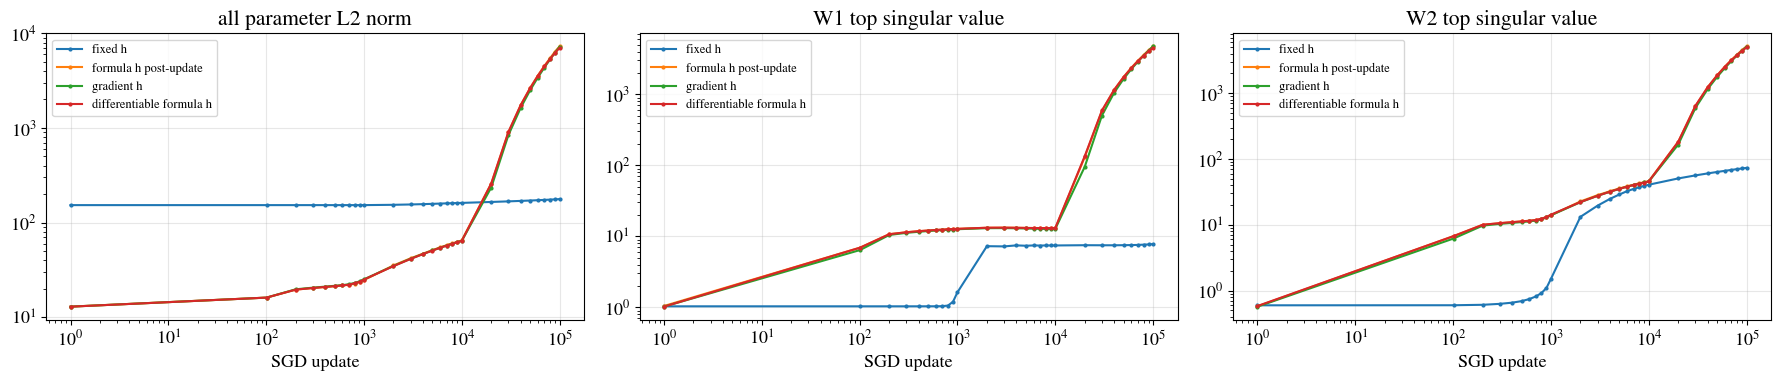

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for label, history in histories.items():
    updates = history["updates"]
    axes[0].plot(updates, history["param_l2"], marker="o", markersize=2, label=label)
    axes[1].plot(updates, history["W1_top"], marker="o", markersize=2, label=label)
    axes[2].plot(updates, history["W2_top"], marker="o", markersize=2, label=label)

axes[0].set_title("all parameter L2 norm")
axes[1].set_title("W1 top singular value")
axes[2].set_title("W2 top singular value")

for ax in axes:
    ax.set_xlabel("SGD update")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()


## Is effective h close to either formula?

In [18]:
formula_names = {"h_phi": "phi(b)", "h_dphi": "phi'(b)"}
closeness = {}

for label, history in histories.items():
    model_stats = {"updates": history["updates"]}
    h_eff = history["h_effective"]

    for formula_key, formula_name in formula_names.items():
        h_formula = history[formula_key]
        rows = {"r2": [], "corr": [], "z_mse": [], "top50": [], "top100": [], "relative_diff": []}
        for eff, formula in zip(h_eff, h_formula):
            fit = affine_fit_stats(formula, eff)
            rows["r2"].append(float(fit["r2"]))
            rows["corr"].append(float(fit["corr"]))
            rows["z_mse"].append(float((zscore(eff) - zscore(formula)).square().mean()))
            rows["top50"].append(top_abs_overlap(eff, formula, 50))
            rows["top100"].append(top_abs_overlap(eff, formula, 100))
            rows["relative_diff"].append(float((eff - formula).norm() / formula.norm().clamp_min(1e-12)))
        model_stats[formula_key] = {key: as_numpy(value) for key, value in rows.items()}

    closeness[label] = model_stats

for label, stats in closeness.items():
    print("\n" + label)
    for formula_key, formula_name in formula_names.items():
        final = stats[formula_key]
        print(
            f"  vs {formula_name:7s} | "
            f"R2={final['r2'][-1]: .3f}, corr={final['corr'][-1]: .3f}, "
            f"zMSE={final['z_mse'][-1]: .3f}, top100={final['top100'][-1]: .3f}, "
            f"rel_diff={final['relative_diff'][-1]: .3e}"
        )



fixed h
  vs phi(b)  | R2= 0.328, corr= 0.572, zMSE= 0.854, top100= 0.000, rel_diff= 4.298e+02
  vs phi'(b) | R2= 0.404, corr= 0.635, zMSE= 0.728, top100= 0.000, rel_diff= 8.381e+02

formula h post-update
  vs phi(b)  | R2= 1.000, corr= 1.000, zMSE= 0.000, top100= 1.000, rel_diff= 2.732e-07
  vs phi'(b) | R2= 0.008, corr= 0.090, zMSE= 1.817, top100= 0.060, rel_diff= 1.765e+00

gradient h
  vs phi(b)  | R2= 0.037, corr=-0.191, zMSE= 2.380, top100= 0.050, rel_diff= 9.843e-01
  vs phi'(b) | R2= 0.582, corr=-0.763, zMSE= 3.521, top100= 0.470, rel_diff= 1.119e+00

differentiable formula h
  vs phi(b)  | R2= 0.551, corr= 0.742, zMSE= 0.515, top100= 0.480, rel_diff= 7.812e-01
  vs phi'(b) | R2= 1.000, corr= 1.000, zMSE= 0.000, top100= 1.000, rel_diff= 0.000e+00


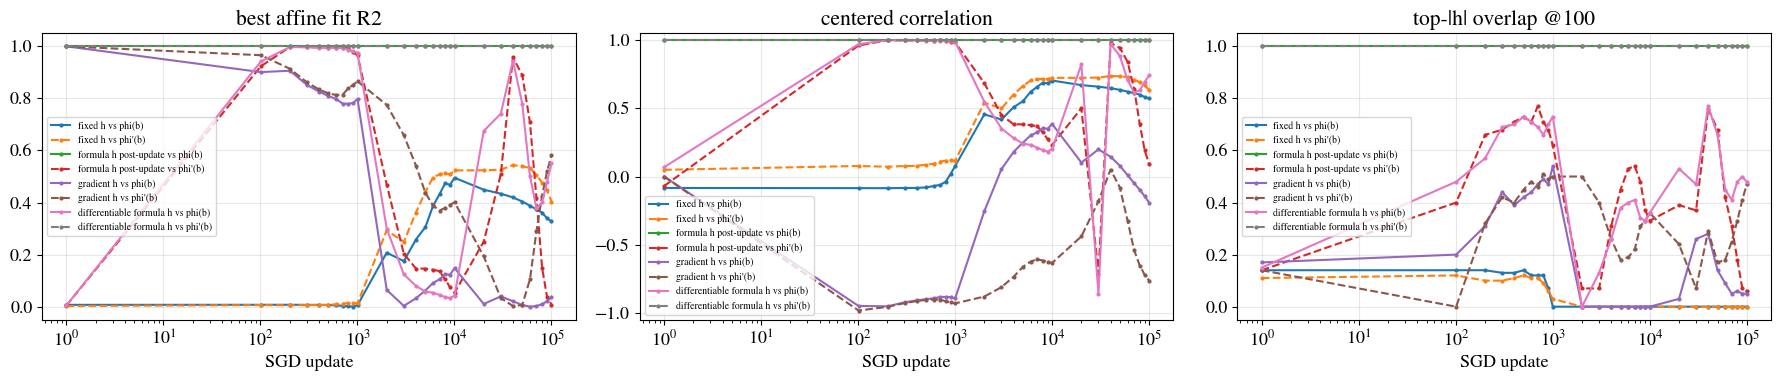

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for label, stats in closeness.items():
    updates = stats["updates"]
    for formula_key, linestyle in [("h_phi", "-"), ("h_dphi", "--")]:
        suffix = formula_names[formula_key]
        axes[0].plot(updates, stats[formula_key]["r2"], linestyle=linestyle, marker="o", markersize=2, label=f"{label} vs {suffix}")
        axes[1].plot(updates, stats[formula_key]["corr"], linestyle=linestyle, marker="o", markersize=2, label=f"{label} vs {suffix}")
        axes[2].plot(updates, stats[formula_key]["top100"], linestyle=linestyle, marker="o", markersize=2, label=f"{label} vs {suffix}")

axes[0].set_title("best affine fit R2")
axes[1].set_title("centered correlation")
axes[2].set_title("top-|h| overlap @100")

for ax in axes:
    ax.set_xlabel("SGD update")
    ax.set_xscale("log")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=7)

axes[0].set_ylim(-0.05, 1.05)
axes[1].set_ylim(-1.05, 1.05)
axes[2].set_ylim(-0.05, 1.05)
plt.tight_layout()
plt.show()


## Does the formula guide the evolution of learned h?

These tests are more meaningful for learned `h` than raw norm comparisons. They compare the direction of change from initialization and the local step direction. A high value means the formula changes in the same visible-space direction as the learned field.


In [20]:
learned_labels = [label for label, spec in MODEL_SPECS.items() if spec["kind"] == "learned"]
evolution = {}

for label in learned_labels:
    history = histories[label]
    h_eff = history["h_effective"]
    model_stats = {"updates": history["updates"]}

    for formula_key in ["h_phi", "h_dphi"]:
        h_formula = history[formula_key]
        delta_cos = []
        delta_corr = []
        projection_fraction = []
        step_cos = [np.nan]

        h0 = h_eff[0]
        f0 = h_formula[0]

        for i in range(len(history["updates"])):
            dh = h_eff[i] - h0
            df = h_formula[i] - f0
            delta_cos.append(cosine(dh, df))
            delta_corr.append(cosine(dh - dh.mean(), df - df.mean()))
            projection_fraction.append(float(((dh @ df) ** 2) / (dh.square().sum() * df.square().sum()).clamp_min(1e-12)))

            if i > 0:
                step_h = h_eff[i] - h_eff[i - 1]
                step_f = h_formula[i] - h_formula[i - 1]
                step_cos.append(cosine(step_h, step_f))

        model_stats[formula_key] = {
            "delta_cos": as_numpy(delta_cos),
            "delta_corr": as_numpy(delta_corr),
            "projection_fraction": as_numpy(projection_fraction),
            "step_cos": as_numpy(step_cos),
        }

    evolution[label] = model_stats

if not learned_labels:
    print("No learned-h checkpoints available.")
else:
    for label, stats in evolution.items():
        print("\n" + label)
        for formula_key, formula_name in formula_names.items():
            values = stats[formula_key]
            print(
                f"  evolution vs {formula_name:7s} | "
                f"delta_cos={values['delta_cos'][-1]: .3f}, "
                f"delta_corr={values['delta_corr'][-1]: .3f}, "
                f"proj_frac={values['projection_fraction'][-1]: .3f}, "
                f"last_step_cos={values['step_cos'][-1]: .3f}"
            )



gradient h
  evolution vs phi(b)  | delta_cos= 0.200, delta_corr=-0.191, proj_frac= 0.040, last_step_cos= 0.471
  evolution vs phi'(b) | delta_cos=-0.828, delta_corr=-0.763, proj_frac= 0.686, last_step_cos=-0.963


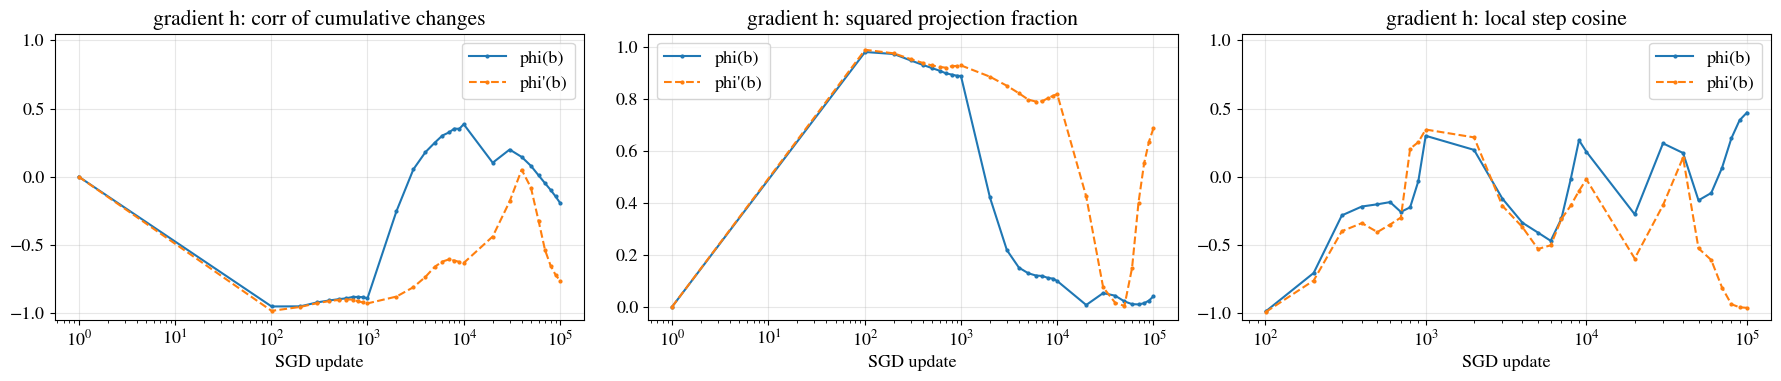

In [21]:
if learned_labels:
    fig, axes = plt.subplots(len(learned_labels), 3, figsize=(18, 4 * len(learned_labels)), squeeze=False)

    for row, label in enumerate(learned_labels):
        stats = evolution[label]
        updates = stats["updates"]
        for formula_key, linestyle in [("h_phi", "-"), ("h_dphi", "--")]:
            suffix = formula_names[formula_key]
            axes[row, 0].plot(updates, stats[formula_key]["delta_corr"], linestyle=linestyle, marker="o", markersize=2, label=suffix)
            axes[row, 1].plot(updates, stats[formula_key]["projection_fraction"], linestyle=linestyle, marker="o", markersize=2, label=suffix)
            axes[row, 2].plot(updates, stats[formula_key]["step_cos"], linestyle=linestyle, marker="o", markersize=2, label=suffix)

        axes[row, 0].set_title(f"{label}: corr of cumulative changes")
        axes[row, 1].set_title(f"{label}: squared projection fraction")
        axes[row, 2].set_title(f"{label}: local step cosine")

    for ax in axes.ravel():
        ax.set_xlabel("SGD update")
        ax.set_xscale("log")
        ax.set_ylim(-1.05, 1.05)
        ax.grid(True, alpha=0.3)
        ax.legend()

    for ax in axes[:, 1]:
        ax.set_ylim(-0.05, 1.05)
    plt.tight_layout()
    plt.show()


## Final h Maps

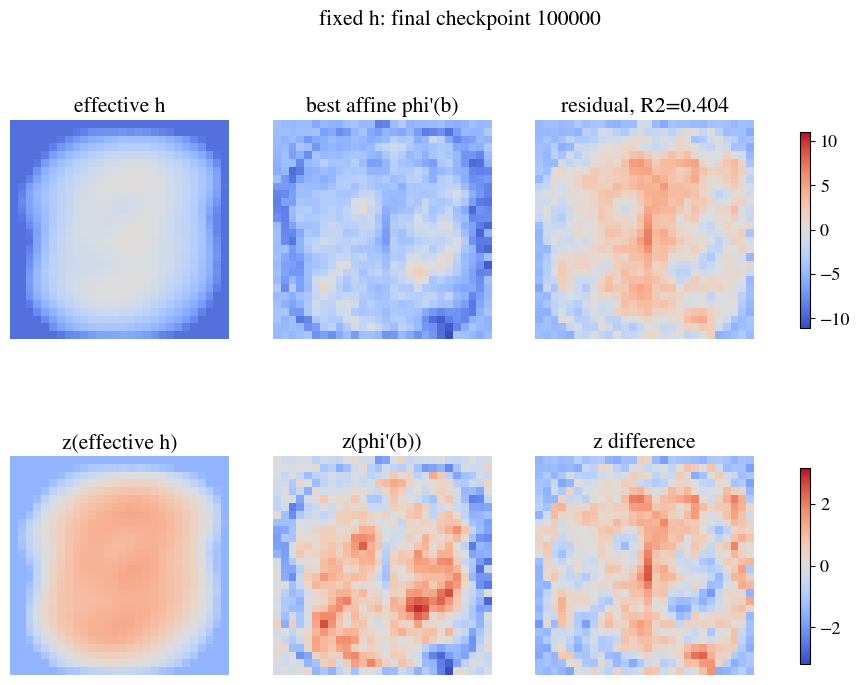

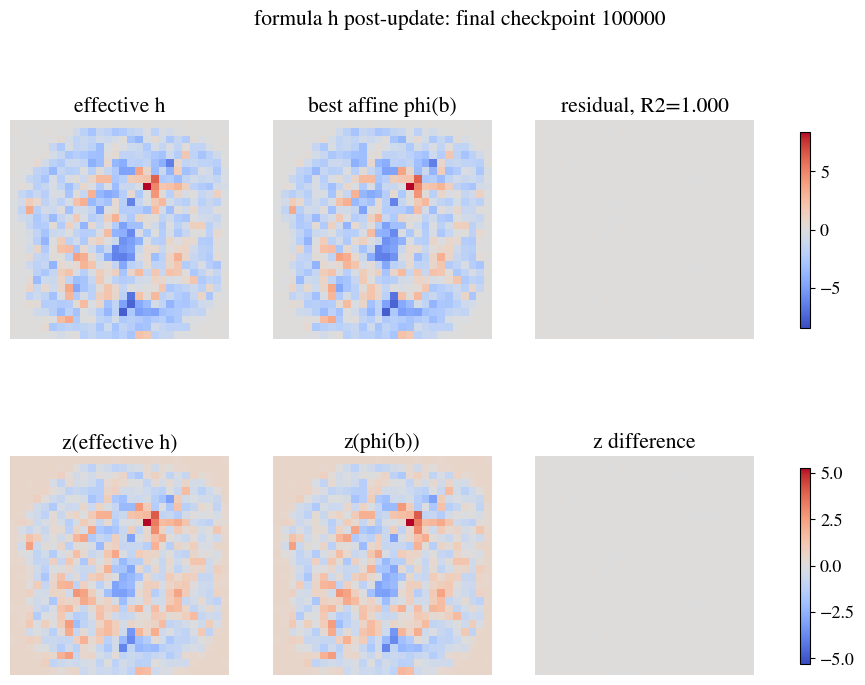

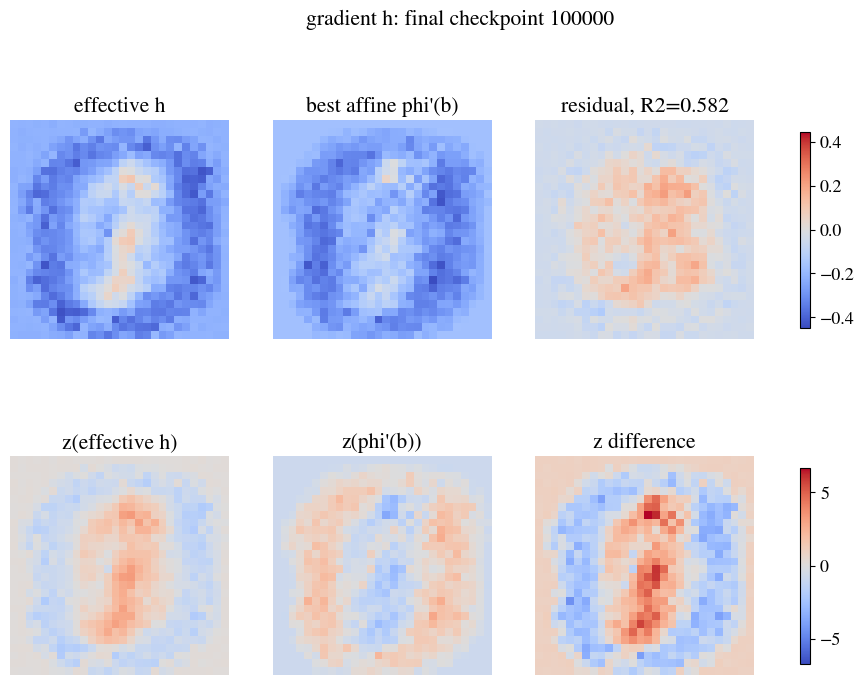

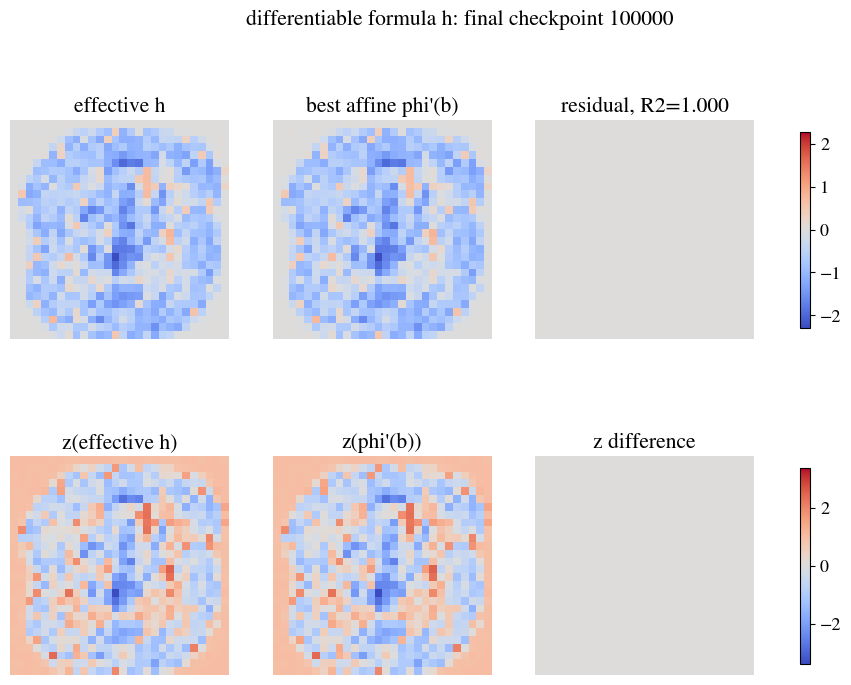

In [22]:
for label, history in histories.items():
    final_h = history["h_effective"][-1]
    final_phi = history["h_phi"][-1]
    final_dphi = history["h_dphi"][-1]

    fit_phi = affine_fit_stats(final_phi, final_h)
    fit_dphi = affine_fit_stats(final_dphi, final_h)
    best_key, best_formula, best_fit = ("phi(b)", final_phi, fit_phi)
    if float(fit_dphi["r2"]) > float(fit_phi["r2"]):
        best_key, best_formula, best_fit = ("phi'(b)", final_dphi, fit_dphi)

    fig, axes = plt.subplots(2, 3, figsize=(12, 8))

    vmax_raw = max(
        float(final_h.abs().max()),
        float(best_fit["fit"].abs().max()),
        float(best_fit["residual"].abs().max()),
    )
    im0 = show_field(axes[0, 0], final_h, "effective h", vmax_raw)
    show_field(axes[0, 1], best_fit["fit"], f"best affine {best_key}", vmax_raw)
    show_field(axes[0, 2], best_fit["residual"], f"residual, R2={float(best_fit['r2']):.3f}", vmax_raw)

    z_h = zscore(final_h)
    z_formula = zscore(best_formula)
    z_diff = z_h - z_formula
    vmax_z = max(float(z_h.abs().max()), float(z_formula.abs().max()), float(z_diff.abs().max()))
    im1 = show_field(axes[1, 0], z_h, "z(effective h)", vmax_z)
    show_field(axes[1, 1], z_formula, f"z({best_key})", vmax_z)
    show_field(axes[1, 2], z_diff, "z difference", vmax_z)

    fig.colorbar(im0, ax=axes[0, :].ravel().tolist(), shrink=0.7)
    fig.colorbar(im1, ax=axes[1, :].ravel().tolist(), shrink=0.7)
    fig.suptitle(f"{label}: final checkpoint {int(history['updates'][-1])}")
    plt.show()
